# Optimización Multiobjetivo de Motores Eléctricos
## jMetalPy — NSGA-II, NSGA-III, SPEA2

**Dataset:** `Opt_dataset_4Objectives_CC.csv`  
**Ruta:** `Datos/01_Optimización/Opt_dataset_4Objectives_CC.csv`

### Mapeo correcto de objetivos
| Columna CSV | Rango          | Variable Técnica | Descripción                  | Dirección |
|-------------|----------------|------------------|------------------------------|----------|
| `y1`        | [4.46, 9.71]   | TC(x)            | Coste total de materiales     | MIN ↓    |
| `y2`        | [0.00, 0.55]   | T_cogPP(x)       | Par de cogging (sin carga)    | MIN ↓    |
| `y3`        | [-0.92, -0.66] | −η_ed(x)         | Eficiencia negada             | MIN ↓    |
| `y4`        | [0.00, 0.51]   | T_rippPP(x)      | Rizado de par (con carga)     | MIN ↓    |

---
## 1. Importaciones

In [1]:
import numpy as np
import pandas as pd
import warnings
import logging
import sys
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
logging.getLogger('jmetal').setLevel(logging.WARNING)

# ── Sklearn ────────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

# ── jMetalPy ───────────────────────────────────────────────────────────────
from jmetal.core.problem import FloatProblem
from jmetal.core.solution import FloatSolution
from jmetal.core.quality_indicator import (
    GenerationalDistance,
    InvertedGenerationalDistance,
    EpsilonIndicator,
    HyperVolume
)


from jmetal.operator.crossover import SBXCrossover
from jmetal.operator.mutation import PolynomialMutation
from jmetal.algorithm.multiobjective.nsgaii import NSGAII
from jmetal.algorithm.multiobjective.nsgaiii import NSGAIII
from jmetal.algorithm.multiobjective.nsgaiii import UniformReferenceDirectionFactory
from jmetal.algorithm.multiobjective.spea2 import SPEA2 as SPEA2_jmetal
from jmetal.util.termination_criterion import StoppingByEvaluations
from jmetal.util.solution import get_non_dominated_solutions

print('Importaciones completadas.')

Importaciones completadas.


In [ ]:
COLOR_BASE = "#00929a"
COLOR_OSCURO = "#006d73"
COLOR_CLARO = "#4bb8be"
COLOR_MUY_CLARO = "#d9f1f2"
COLOR_GRID = "#b7dfe2"
COLOR_TEXTO = "#1f2d2f"

---
## 2. Carga y Exploración del Dataset

In [ ]:
df = pd.read_csv(r'Datos\01_Optimización\Opt_dataset_4Objectives_CC.csv')
Y_entero = df.iloc[:, 6:10].values
Y_MIN_COGGING_ENTERO = float(Y_entero[:, 1].min())
Y_MIN_RIZADO_ENTERO  = float(Y_entero[:, 3].min())

num_muestras = int(len(df)*0.5)
df = df.sample(n=num_muestras, random_state=42).reset_index(drop=True)

X = df.iloc[:, 0:6].values
Y = df.iloc[:, 6:10].values

x_min = np.min(X, axis=0)
x_max = np.max(X, axis=0)
xl    = x_min.tolist()
xu    = x_max.tolist()

Y_MIN_COGGING = float(Y[:, 1].min())
Y_MIN_RIZADO  = float(Y[:, 3].min())

print(f'Dataset: {df.shape[0]} obs, {df.shape[1]} cols')

print(f'Variables (X): {X.shape[1]} | Objetivos (Y): {Y.shape[1]}')
print('\nRanges del espacio de búsqueda:')
for name, lo, hi in zip(['hm','alfa_m','er','dsi','bst','bss'], x_min, x_max):
    print(f'  {name}: [{lo:.2f}, {hi:.2f}]')
print('\nRanges de objetivos:')
for name, lo, hi in zip(['y1 TC','y2 Cogging','y3 -η_ed','y4 Rizado'],
                         Y.min(axis=0), Y.max(axis=0)):
    print(f'  {name}: [{lo:.4f}, {hi:.4f}]')

Dataset: 850 obs, 10 cols
Variables (X): 6 | Objetivos (Y): 4

Ranges del espacio de búsqueda:
  hm: [1.00, 4.00]
  alfa_m: [0.70, 1.00]
  er: [0.60, 2.00]
  dsi: [0.00, 2.50]
  bst: [45.00, 49.50]
  bss: [3.50, 5.90]

Ranges de objetivos:
  y1 TC: [4.4581, 9.7117]
  y2 Cogging: [0.0002, 0.5543]
  y3 -η_ed: [-0.9219, -0.6796]
  y4 Rizado: [0.0014, 0.5130]


---
## 3. Selección del Modelo Sustituto (Surrogate Model)

In [ ]:
rf  = RandomForestRegressor(random_state=42)
xgb = MultiOutputRegressor(HistGradientBoostingRegressor(random_state=42))

param_grid_rf = {'n_estimators': [50, 100], 'max_depth': [10, 20, None]}
param_grid_xgb = {
    'estimator__max_iter':      [50, 100],
    'estimator__learning_rate': [0.05, 0.1, 0.2]}

print('Entrenando Random Forest (6 combinaciones)...')
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='r2', n_jobs=-1)
grid_rf.fit(X, Y)

print('Entrenando Gradient Boosting / XGB (6 combinaciones)...')
grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=5, scoring='r2', n_jobs=-1)
grid_xgb.fit(X, Y)

resultados = []
for i in range(len(grid_rf.cv_results_['params'])):
    resultados.append({
        'Modelo': 'Random Forest',
        'Hiperparametros': str(grid_rf.cv_results_['params'][i]),
        'R2_Media_CV': round(grid_rf.cv_results_['mean_test_score'][i], 4),
        'R2_Desviacion': round(grid_rf.cv_results_['std_test_score'][i], 4)
    })
for i in range(len(grid_xgb.cv_results_['params'])):
    p = {k.replace('estimator__', ''): v for k, v in grid_xgb.cv_results_['params'][i].items()}
    resultados.append({
        'Modelo': 'Gradient Boosting (XGB)',
        'Hiperparametros': str(p),
        'R2_Media_CV': round(grid_xgb.cv_results_['mean_test_score'][i], 4),
        'R2_Desviacion': round(grid_xgb.cv_results_['std_test_score'][i], 4)})

df_surr = pd.DataFrame(resultados).sort_values('R2_Media_CV', ascending=False).reset_index(drop=True)
print('\n--- RANKING MODELOS SUSTITUTOS ---')
print(df_surr.to_string())

Entrenando Random Forest (6 combinaciones)...
Entrenando Gradient Boosting / XGB (6 combinaciones)...

--- RANKING MODELOS SUSTITUTOS ---
                     Modelo                           Hiperparametros  R2_Media_CV  R2_Desviacion
0   Gradient Boosting (XGB)   {'learning_rate': 0.2, 'max_iter': 100}       0.9436         0.0061
1   Gradient Boosting (XGB)   {'learning_rate': 0.1, 'max_iter': 100}       0.9409         0.0083
2   Gradient Boosting (XGB)    {'learning_rate': 0.2, 'max_iter': 50}       0.9392         0.0074
3   Gradient Boosting (XGB)    {'learning_rate': 0.1, 'max_iter': 50}       0.9272         0.0102
4   Gradient Boosting (XGB)  {'learning_rate': 0.05, 'max_iter': 100}       0.9266         0.0098
5   Gradient Boosting (XGB)   {'learning_rate': 0.05, 'max_iter': 50}       0.8971         0.0129
6             Random Forest  {'max_depth': None, 'n_estimators': 100}       0.8854         0.0453
7             Random Forest    {'max_depth': 20, 'n_estimators': 100}       0.

In [ ]:
print('Entrenando XGB óptimo (lr=0.2, iter=100) sobre todo el dataset...')
xgb_model = MultiOutputRegressor(
    HistGradientBoostingRegressor(learning_rate=0.2, max_iter=100, random_state=42))
xgb_model.fit(X, Y)
print('Modelo sustituto listo.')

Entrenando XGB óptimo (lr=0.2, iter=100) sobre todo el dataset...
Modelo sustituto listo.


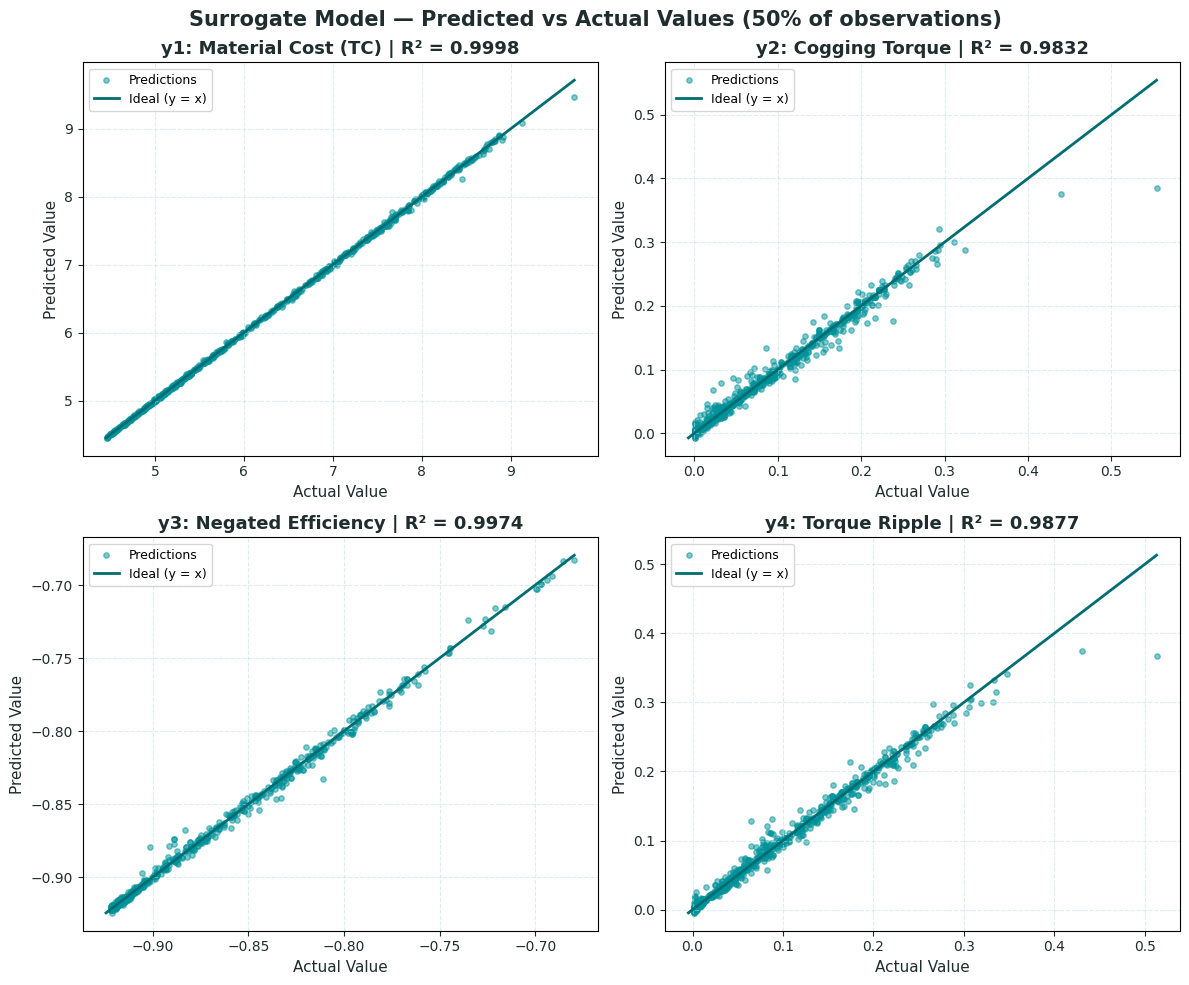

In [6]:
Y_pred     = xgb_model.predict(X)
n_outputs  = Y.shape[1]
obj_labels = ['y1: Material Cost (TC)', 'y2: Cogging Torque', 'y3: Negated Efficiency', 'y4: Torque Ripple']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i in range(n_outputs):
    ax = axes[i]

    ax.scatter(Y[:, i], Y_pred[:, i],
               color=COLOR_BASE, alpha=0.5, s=15, label='Predictions')

    min_val = min(Y[:, i].min(), Y_pred[:, i].min())
    max_val = max(Y[:, i].max(), Y_pred[:, i].max())
    ax.plot([min_val, max_val], [min_val, max_val],
            color=COLOR_OSCURO, linewidth=2, label='Ideal (y = x)')

    r2 = r2_score(Y[:, i], Y_pred[:, i])

    ax.set_xlabel('Actual Value', fontsize=11, color=COLOR_TEXTO)
    ax.set_ylabel('Predicted Value', fontsize=11, color=COLOR_TEXTO)
    ax.set_title(f'{obj_labels[i]} | R² = {r2:.4f}',
                 fontsize=13, fontweight='bold', color=COLOR_TEXTO)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5, color=COLOR_GRID)
    ax.tick_params(colors=COLOR_TEXTO)

plt.suptitle('Surrogate Model — Predicted vs Actual Values (50% of observations)', fontsize=15, fontweight='bold', color=COLOR_TEXTO)
plt.tight_layout()
plt.show()


---
## 4. Operadores Genéticos

**Justificación:**
- **SBX** (`eta=15`): estándar para variables continuas; equilibra diversidad y convergencia (Deb, 2001).
- **PM** (`prob=1/n_var`): recomendación canónica. `eta=20` genera mutaciones pequeñas.
- **NSGA-III** usa `UniformReferenceDirectionFactory` con 12 divisiones → 455 direcciones Das-Dennis.

In [7]:
crossover_sbx = SBXCrossover(probability=0.9, distribution_index=15.0)
mutation_pm   = PolynomialMutation(probability=1.0/6.0, distribution_index=20.0)
terminacion   = StoppingByEvaluations(max_evaluations=15000)

# POP-SIZE
pop_size = 100
offspring_size = 100

print('Operadores configurados.')
print(f'  jMetalPy → {terminacion.max_evaluations} evaluaciones max')
print(f'  pop_size → {pop_size} individuos')
print(f'  offspring_size → {offspring_size} descendientes')

Operadores configurados.
  jMetalPy → 15000 evaluaciones max
  pop_size → 100 individuos
  offspring_size → 100 descendientes


---
## B.1 Definición del Problema (jMetalPy)

In [ ]:
class MotorProblem_jmetal(FloatProblem):
    """Problema MOO del motor para jMetalPy. El surrogate XGB evalúa los 4 objetivos."""
    def __init__(self, modelo):
        super().__init__()
        self.obj_directions = [self.MINIMIZE] * 4
        self.obj_labels     = ['TC_Coste', 'T_cogPP', 'Efic_Negada', 'T_rippPP']
        self.lower_bound    = xl
        self.upper_bound    = xu
        self.modelo         = modelo

    def number_of_variables(self)  -> int: return 6
    def number_of_objectives(self) -> int: return 4
    def number_of_constraints(self)-> int: return 0
    def name(self) -> str: return 'Motor_Electrico_4Obj'

    def evaluate(self, solution: FloatSolution) -> FloatSolution:
        x      = np.array(solution.variables).reshape(1, -1)
        y_pred = self.modelo.predict(x)[0]
        y_pred[1] = max(Y_MIN_COGGING, y_pred[1])  
        y_pred[3] = max(Y_MIN_RIZADO,  y_pred[3]) 
        for i in range(self.number_of_objectives()):
            solution.objectives[i] = float(y_pred[i])
        return solution

problem_jmetal = MotorProblem_jmetal(xgb_model)
print(f'Problema: {problem_jmetal.number_of_variables()} variables, {problem_jmetal.number_of_objectives()} objetivos')

Problema: 6 variables, 4 objetivos


## B.2 Ejecución de Algoritmos jMetalPy

In [9]:
# ── NSGA-II: Ranking de Pareto + Crowding Distance ──────────────────────────
print('Ejecutando NSGA-II (jMetalPy)...')
nsga2_jmetal = NSGAII(
    problem=problem_jmetal,
    population_size=pop_size,
    offspring_population_size=offspring_size,
    mutation=mutation_pm,
    crossover=crossover_sbx,
    termination_criterion=terminacion
)
nsga2_jmetal.run()
frente_nsga2 = get_non_dominated_solutions(nsga2_jmetal.result())
print(f'NSGA-II  → {len(frente_nsga2)} soluciones en el frente de Pareto')

[2026-03-25 14:14:03,311] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-25 14:14:03,315] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...


Ejecutando NSGA-II (jMetalPy)...


[2026-03-25 14:14:07,696] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-25 14:14:07,697] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-25 14:26:36,163] [jmetal.core.algorithm] [DEBUG] Finished!


NSGA-II  → 95 soluciones en el frente de Pareto


In [10]:
print('Ejecutando NSGA-III (jMetalPy)...')
nsga3_jmetal = NSGAIII(
    problem=problem_jmetal,
    population_size=pop_size,
    reference_directions=UniformReferenceDirectionFactory(4, n_points=120),
    mutation=mutation_pm,
    crossover=crossover_sbx,
    termination_criterion=terminacion
)
nsga3_jmetal.run()
frente_nsga3 = get_non_dominated_solutions(nsga3_jmetal.result())
print(f'NSGA-III → {len(frente_nsga3)} soluciones en el frente de Pareto')


[2026-03-25 14:26:36,198] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-25 14:26:36,204] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...


Ejecutando NSGA-III (jMetalPy)...


[2026-03-25 14:26:41,113] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-25 14:26:41,122] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-25 14:39:46,695] [jmetal.core.algorithm] [DEBUG] Finished!


NSGA-III → 85 soluciones en el frente de Pareto


In [11]:
# ── SPEA2: Strength Pareto + Archive externo ─────────────────────────────────
print('Ejecutando SPEA2 (jMetalPy)...')
spea2_jmetal = SPEA2_jmetal(
    problem=problem_jmetal,
    population_size=pop_size,
    offspring_population_size=offspring_size,
    mutation=mutation_pm,
    crossover=crossover_sbx,
    termination_criterion=terminacion
)
spea2_jmetal.run()
frente_spea2 = get_non_dominated_solutions(spea2_jmetal.result())
print(f'SPEA2    → {len(frente_spea2)} soluciones en el frente de Pareto')

[2026-03-25 14:39:46,752] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-25 14:39:46,760] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...


Ejecutando SPEA2 (jMetalPy)...


[2026-03-25 14:39:50,889] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-25 14:39:50,890] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-25 14:46:29,361] [jmetal.core.algorithm] [DEBUG] Finished!


SPEA2    → 100 soluciones en el frente de Pareto


## B.3 Guardar Última Generación de Cada Algoritmo

In [ ]:
cols_x        = ['hm', 'alfa_m', 'er', 'dsi', 'bst', 'bss']
frentes_todos = [frente_nsga2, frente_nsga3, frente_spea2]   
nombres_todos = ['NSGA-II', 'NSGA-III', 'SPEA2']            

for frente, nombre in zip(frentes_todos, nombres_todos):
    filas = []
    for sol in frente:
        fila = dict(zip(cols_x, sol.variables))
        fila['y1_TC_Coste']  = float(sol.objectives[0])
        fila['y2_Cogging']   = float(sol.objectives[1])
        fila['y3_Efic_Neg']  = float(sol.objectives[2])   
        fila['y4_Rizado']    = float(sol.objectives[3])
        filas.append(fila)
    fname = f'Datos/Transformados/ultima_gen_jmetal_{nombre}_50.csv'
    pd.DataFrame(filas).to_csv(fname, index=False)
    print(f'  {nombre:8s} → {len(filas):3d} soluciones guardadas en {fname}')

print('\nTodas las últimas generaciones exportadas.')


  NSGA-II  →  95 soluciones guardadas en ultima_gen_jmetal_NSGA-II_50.csv
  NSGA-III →  85 soluciones guardadas en ultima_gen_jmetal_NSGA-III_50.csv
  SPEA2    → 100 soluciones guardadas en ultima_gen_jmetal_SPEA2_50.csv

Todas las últimas generaciones exportadas.


## B.4 Extracción de Resultados como DataFrames

In [ ]:
def frente_a_dataframe(frente_soluciones):
    """
    Convierte lista de FloatSolution de jMetalPy a DataFrame.
    y3 se mantiene en escala original negativa (consistente con pymoo).
    """
    filas = []
    for sol in frente_soluciones:
        filas.append({
            'hm':           sol.variables[0],'alfa_m':       sol.variables[1],
            'er':           sol.variables[2],'dsi':          sol.variables[3],
            'bst':          sol.variables[4],'bss':          sol.variables[5],
            'y1_TC_Coste':  float(sol.objectives[0]),
            'y2_Cogging':   float(sol.objectives[1]),
            'y3_Efic_Neg':  float(sol.objectives[2]),   
            'y4_Rizado':    float(sol.objectives[3])
        })
    return pd.DataFrame(filas)


df_nsga2 = frente_a_dataframe(frente_nsga2)
df_nsga3 = frente_a_dataframe(frente_nsga3)   
df_spea2 = frente_a_dataframe(frente_spea2)

for nombre, df_alg in [('NSGA-II', df_nsga2), ('NSGA-III', df_nsga3), ('SPEA2', df_spea2)]:
    print(f'DataFrame {nombre}: {df_alg.shape}')

print('\n--- NSGA-II (muestra) ---')
display(df_nsga2.head().round(4))

print('\n--- NSGA-III (muestra) ---')
display(df_nsga3.head().round(4))

print('\n--- SPEA2 (muestra) ---')
display(df_spea2.head().round(4))


DataFrame NSGA-II: (95, 10)
DataFrame NSGA-III: (85, 10)
DataFrame SPEA2: (100, 10)

--- NSGA-II (muestra) ---


,hm,alfa_m,er,dsi,bst,bss,y1_TC_Coste,y2_Cogging,y3_Efic_Neg,y4_Rizado
0,1.0128,0.7158,1.7404,2.4024,46.3490,5.6658,4.4123,0.0134,-0.7412,0.0314
1,1.0568,0.7085,0.7202,2.4419,45.2409,5.7429,4.4679,0.0002,-0.7436,0.0056
2,2.6182,0.7912,1.6126,0.7615,45.2312,4.7953,6.7374,0.0151,-0.9200,0.0014
3,3.3911,0.9623,0.6562,1.0683,47.7936,3.7535,8.4689,0.0576,-0.9317,0.0815
4,3.7486,0.9623,0.6562,1.0683,47.8418,4.1045,8.8663,0.0305,-0.9301,0.0539



--- NSGA-III (muestra) ---


,hm,alfa_m,er,dsi,bst,bss,y1_TC_Coste,y2_Cogging,y3_Efic_Neg,y4_Rizado
0,1.0163,0.7719,1.5092,0.8129,45.0030,4.9900,4.6509,0.0166,-0.8961,0.0014
1,1.1221,0.7887,1.0761,0.1677,45.0052,4.8458,5.0431,0.0168,-0.9144,0.0690
2,1.0663,0.7723,1.0353,0.8128,45.0581,5.1017,4.6540,0.0040,-0.8966,0.0014
3,2.2910,0.7698,0.6825,0.7805,45.1376,5.1862,6.0254,0.0002,-0.9177,0.0020
4,1.0791,0.7314,1.0807,0.1186,45.0609,5.0306,4.7016,0.0168,-0.9061,0.0670



--- SPEA2 (muestra) ---


,hm,alfa_m,er,dsi,bst,bss,y1_TC_Coste,y2_Cogging,y3_Efic_Neg,y4_Rizado
0,1.0143,0.9084,1.0458,0.0364,45.2321,4.5471,4.9953,0.2062,-0.9182,0.2290
1,2.7597,0.9281,0.9908,1.8944,48.0629,3.5660,7.6127,0.0345,-0.9257,0.0546
2,3.2534,0.9381,1.7650,1.1651,47.8073,3.7927,7.8785,0.0340,-0.9277,0.0396
3,3.2660,0.9500,1.7650,0.9842,47.8073,3.7768,7.9673,0.0355,-0.9248,0.0375
4,2.2608,0.7801,0.8336,0.5360,45.1518,4.8536,6.3078,0.0179,-0.9193,0.0393


## B.6 Comparativa de Métricas

| Métrica | Qué mide | Mejor |
|---------|----------|-------|
| **PF Size** | Nº de soluciones no dominadas | Mayor diversidad |
| **HV** | Volumen dominado entre el frente y el punto de referencia | Mayor ↑ |
| **GD** | Distancia media de cada solución al frente real (convergencia) | Menor ↓ |
| **IGD** | Distancia media del frente real a la solución más cercana (cobertura) | Menor ↓ |
| **Epsilon** | Margen mínimo para que el frente aproxime al real | Menor ↓ |

In [ ]:
# ── Funcion de dominancia ───────────
def non_dominated_front_jmetal(Y_array: np.ndarray) -> np.ndarray:
    n = len(Y_array)
    dominated = np.zeros(n, dtype=bool)
    for i in range(n):
        if dominated[i]:
            continue
        diff = Y_array - Y_array[i]              
        all_leq = np.all(diff <= 0, axis=1)      
        any_lt  = np.any(diff <  0, axis=1)      
        dominators = all_leq & any_lt
        dominators[i] = False                    
        if np.any(dominators):
            dominated[i] = True
    return np.where(~dominated)[0]

idx_ref = non_dominated_front_jmetal(Y)
F_ref   = Y[idx_ref]
print(f'Frente de referencia: {F_ref.shape[0]} soluciones no dominadas')

Frente de referencia: 254 soluciones no dominadas


In [15]:
percentage_margin = 10
ref_max        = np.amax(F_ref, axis=0)
ref_max_adj    = ref_max.copy()
ref_max_adj[2] = np.amax(np.abs(F_ref[:, 2]))   # y3: abs del máximo
reference_point = list(ref_max_adj * (1 + percentage_margin / 100))

# ── Indicadores jMetalPy ────────────────────────────────────────────────────
ind_gd  = GenerationalDistance(F_ref)
ind_igd = InvertedGenerationalDistance(F_ref)
ind_eps = EpsilonIndicator(F_ref)
ind_hv  = HyperVolume(reference_point)

# ── Calcular métricas ────────────────────────────────────────────────────────
metricas = []
for frente, nombre in zip(frentes_todos, nombres_todos):
    nd_sols = get_non_dominated_solutions(frente)
    F_nd    = np.array([s.objectives for s in nd_sols])
    metricas.append({
        'Algoritmo':  nombre,
        'PF Size':    len(F_nd),
        'HV':       round(ind_hv.compute(F_nd),  4),
        'GD':       round(ind_gd.compute(F_nd),  4),
        'IGD':      round(ind_igd.compute(F_nd), 4),
        'Epsilon':  round(ind_eps.compute(F_nd), 4),
    })

df_metricas = pd.DataFrame(metricas).set_index('Algoritmo')
print('=== COMPARATIVA DE ALGORITMOS — jMetalPy ===\n')
display(df_metricas)

mejor_alg = df_metricas['IGD'].idxmin()
print(f'\n→ Mejor algoritmo según IGD: {mejor_alg}')
print(f'  IGD = {df_metricas.loc[mejor_alg, "IGD"]:.4f}')

=== COMPARATIVA DE ALGORITMOS — jMetalPy ===



,PF Size,HV,GD,IGD,Epsilon
Algoritmo,,,,,
NSGA-II,95,0.5317,0.0423,0.0073,0.0198
NSGA-III,85,0.5203,0.0415,0.0324,0.0868
SPEA2,100,0.5275,0.0471,0.0065,0.0125



→ Mejor algoritmo según IGD: SPEA2
  IGD = 0.0065


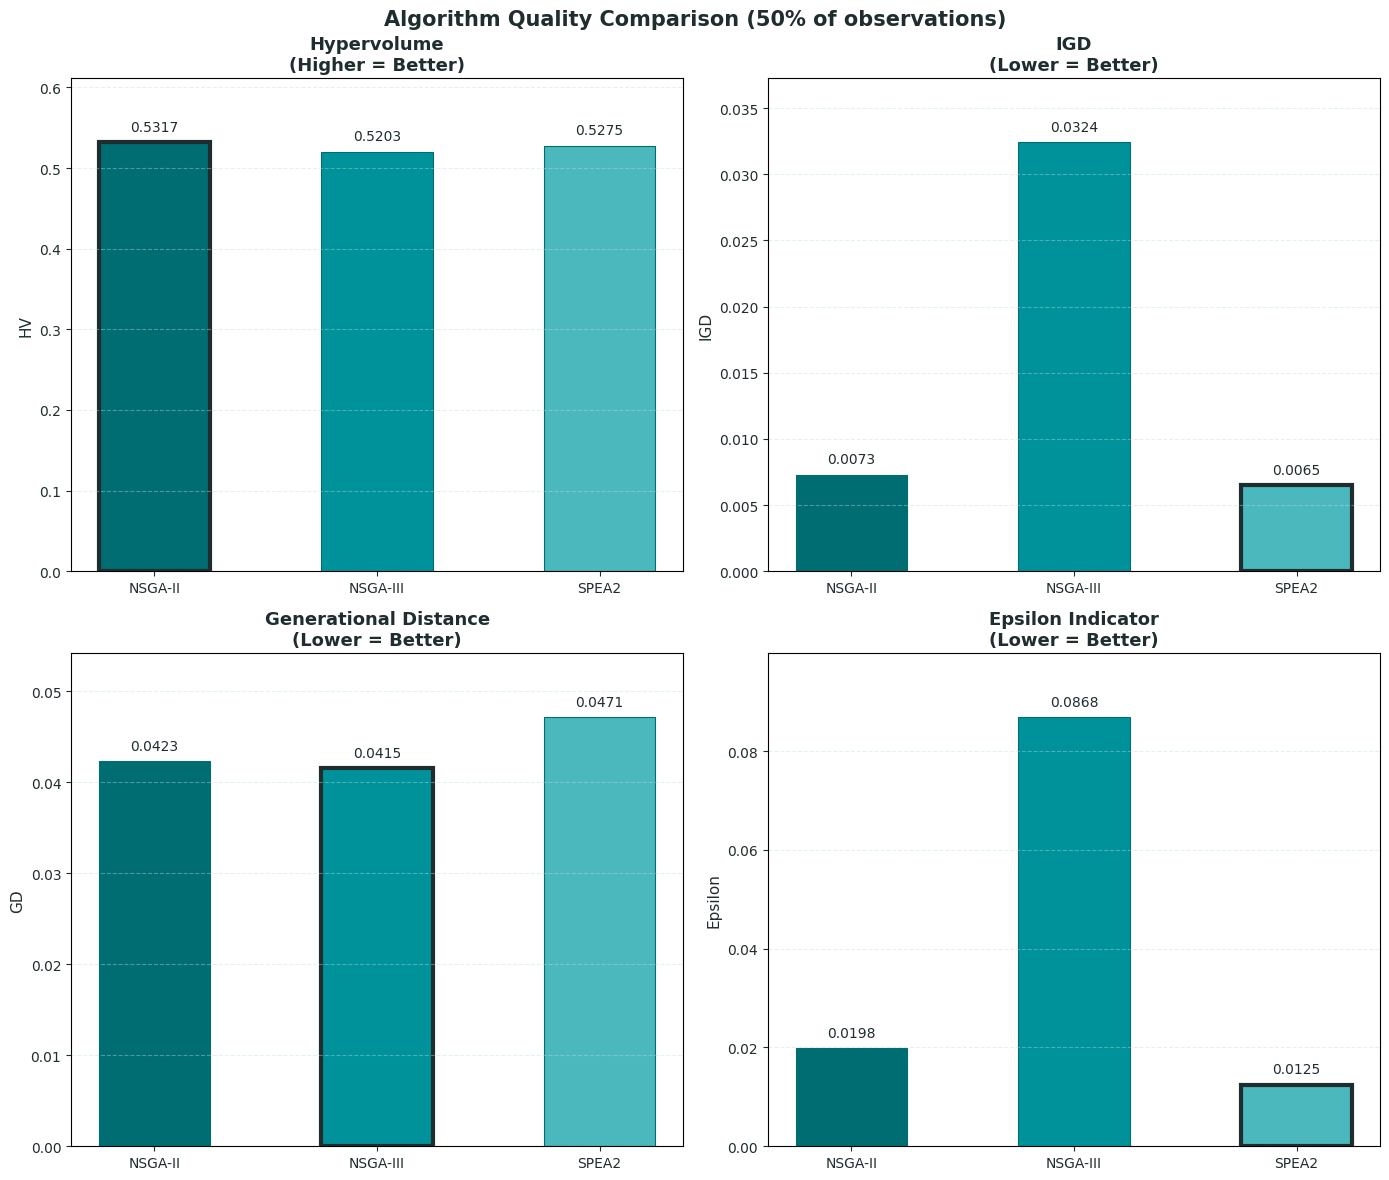

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

colores_alg = [COLOR_OSCURO, COLOR_BASE, COLOR_CLARO]
algoritmos  = df_metricas.index.tolist()

metricas_plot = [('HV',      'Hypervolume\n(Higher = Better)',            'max'),
    ('IGD',     'IGD\n(Lower = Better)',                     'min'),
    ('GD',      'Generational Distance\n(Lower = Better)',   'min'),
    ('Epsilon', 'Epsilon Indicator\n(Lower = Better)',       'min'),]

for ax, (metrica, titulo, criterio) in zip(axes, metricas_plot):
    valores = df_metricas[metrica]
    bars = ax.bar(
        algoritmos, valores,
        color=colores_alg[:len(algoritmos)],
        edgecolor=COLOR_OSCURO, linewidth=0.8, width=0.5
    )
    ax.set_title(titulo, fontsize=13, fontweight='bold', color=COLOR_TEXTO)
    ax.set_ylabel(metrica, fontsize=11, color=COLOR_TEXTO)
    ax.set_ylim(0, valores.max() * 1.15)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4, color=COLOR_GRID)
    ax.tick_params(colors=COLOR_TEXTO)

    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + valores.max() * 0.02,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, color=COLOR_TEXTO)

    mejor = valores.idxmax() if criterio == 'max' else valores.idxmin()
    idx_mejor = algoritmos.index(mejor)
    bars[idx_mejor].set_edgecolor(COLOR_TEXTO)
    bars[idx_mejor].set_linewidth(3)

plt.suptitle('Algorithm Quality Comparison (50% of observations)', fontsize=15, fontweight='bold', color=COLOR_TEXTO)
plt.tight_layout()
plt.show()

## B.5 Visualización del Frente de Pareto

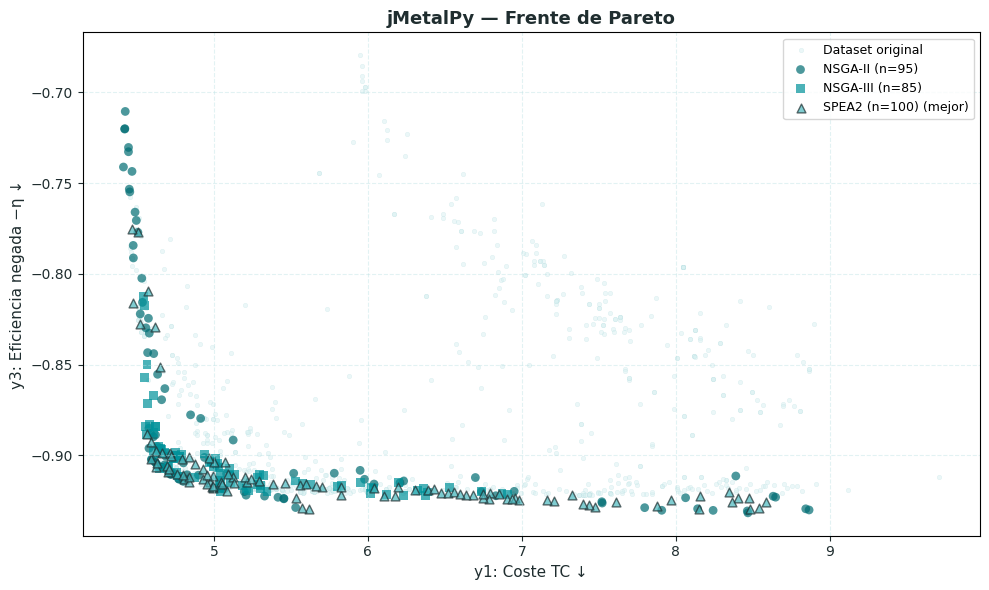

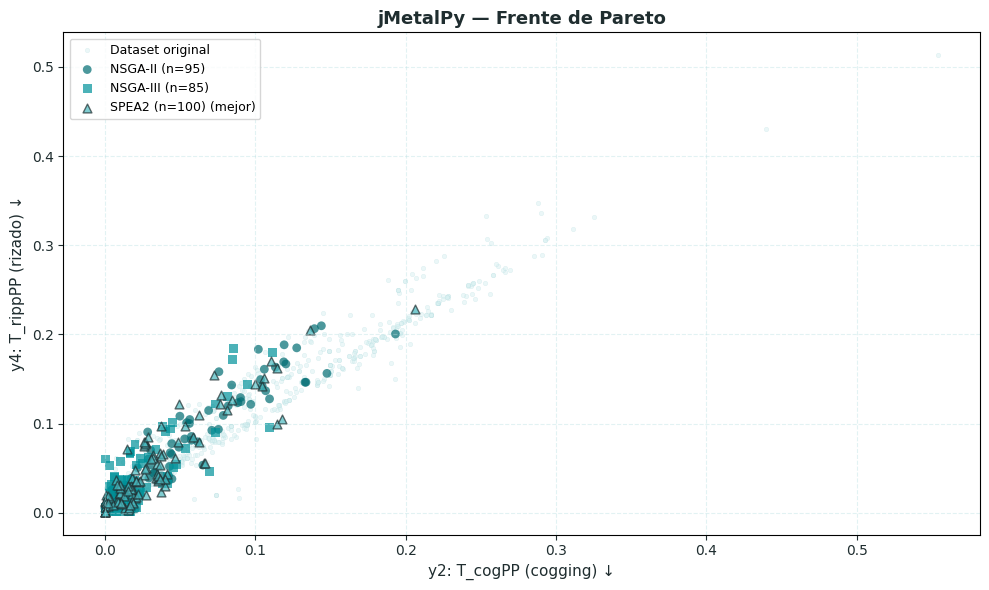

In [17]:
def pareto_plot_jmetal(dfs, nombres_alg, col_x, col_y, label_x, label_y, mejor=None):
    colores_alg = [COLOR_OSCURO, COLOR_BASE, COLOR_CLARO]
    marcadores  = ['o', 's', '^']
    col_idx     = {'y1_TC_Coste': 0, 'y2_Cogging': 1, 'y3_Efic_Neg': 2, 'y4_Rizado': 3}

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(Y[:, col_idx[col_x]], Y[:, col_idx[col_y]],
               color=COLOR_MUY_CLARO, edgecolors=COLOR_GRID, alpha=0.5, s=10,
               label='Dataset original', linewidths=0.3)

    for df_alg, nombre, color, marker in zip(dfs, nombres_alg, colores_alg, marcadores):
        lw = 1 if nombre == mejor else 0
        ec = COLOR_TEXTO if nombre == mejor else 'none'
        ax.scatter(df_alg[col_x], df_alg[col_y],
                   color=color, marker=marker, alpha=0.7, s=40,
                   edgecolors=ec, linewidths=lw,
                   label=f'{nombre} (n={len(df_alg)})' + (' (mejor)' if nombre == mejor else ''))

    ax.set_xlabel(label_x, fontsize=11, color=COLOR_TEXTO)
    ax.set_ylabel(label_y, fontsize=11, color=COLOR_TEXTO)
    ax.set_title('jMetalPy — Frente de Pareto', fontsize=13, fontweight='bold', color=COLOR_TEXTO)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4, color=COLOR_GRID)
    ax.tick_params(colors=COLOR_TEXTO)
    plt.tight_layout()
    plt.show()


todos_df = [df_nsga2, df_nsga3, df_spea2]
_mejor = mejor_alg if 'mejor_alg' in dir() else None

pareto_plot_jmetal(todos_df, nombres_todos,
                   'y1_TC_Coste', 'y3_Efic_Neg',
                   'y1: Coste TC ↓', 'y3: Eficiencia negada −η ↓',
                   mejor=_mejor)

pareto_plot_jmetal(todos_df, nombres_todos,
                   'y2_Cogging', 'y4_Rizado',
                   'y2: T_cogPP (cogging) ↓', 'y4: T_rippPP (rizado) ↓',
                   mejor=_mejor)


## B.7 Top-5 del Mejor Algoritmo por TOPSIS

In [ ]:
rango           = np.max(Y_entero, axis=0) - np.min(Y, axis=0)
IDEAL_FIJO      = np.min(Y_entero, axis=0) - 0.1 * rango
ANTI_IDEAL_FIJO = np.max(Y_entero, axis=0) + 0.1 * rango
IDEAL_FIJO[1]   = Y_MIN_COGGING_ENTERO
IDEAL_FIJO[3]   = Y_MIN_RIZADO_ENTERO
pesos_iguales = np.ones(4) / 4   

def topsis_ranking(F_matrix, pesos=None):
    if pesos is None:
        pesos = pesos_iguales     

    rango_norm = ANTI_IDEAL_FIJO - IDEAL_FIJO
    rango_norm[rango_norm == 0] = 1e-10
    F_norm          = (F_matrix - IDEAL_FIJO) / rango_norm
    ideal_norm      = np.zeros(F_matrix.shape[1])
    anti_ideal_norm = np.ones(F_matrix.shape[1])

    F_pond          = F_norm          * pesos
    ideal_pond      = ideal_norm      * pesos
    anti_ideal_pond = anti_ideal_norm * pesos

    d_ideal      = np.sqrt(((F_pond - ideal_pond)**2).sum(axis=1))
    d_anti_ideal = np.sqrt(((F_pond - anti_ideal_pond)**2).sum(axis=1))

    score = d_anti_ideal / (d_ideal + d_anti_ideal + 1e-10)
    return np.argsort(-score), score


frentes_map = {'NSGA-II': frente_nsga2, 'NSGA-III': frente_nsga3, 'SPEA2': frente_spea2}
frente_mejor = get_non_dominated_solutions(frentes_map[mejor_alg])

F_mejor = np.array([s.objectives for s in frente_mejor])
X_mejor = np.array([s.variables  for s in frente_mejor])

idx_sorted, scores = topsis_ranking(F_mejor)
idx_top7 = idx_sorted[:7]

df_top7 = pd.DataFrame(X_mejor[idx_top7], columns=cols_x)

df_top7['y1_TC_Coste']          = F_mejor[idx_top7, 0]
df_top7['y2_Cogging']           = np.clip(F_mejor[idx_top7, 1], Y_MIN_COGGING_ENTERO, None)
df_top7['y3_Eficiencia_real_%'] = -F_mejor[idx_top7, 2]   
df_top7['y4_Rizado']            = np.clip(F_mejor[idx_top7, 3], Y_MIN_RIZADO_ENTERO,  None)
df_top7['score'] = scores[idx_top7]

print(f'\n=== SOLUCIÓN IDEAL — {mejor_alg} ===')
print(f'TC Coste        : {IDEAL_FIJO[0]:.4f}')
print(f'Cogging         : {IDEAL_FIJO[1]:.6f}')
print(f'Eficiencia real : {-IDEAL_FIJO[2]:.4f}')
print(f'Rizado          : {IDEAL_FIJO[3]:.6f}\n')

df_top7 = df_top7.sort_values(by='score', ascending=False)
print(f'=== TOP-7 DISEÑOS — {mejor_alg} ===')
display(df_top7.round(4))

df_top7.to_csv(f'Datos/Transformados/top7_motores_jmetal_{mejor_alg}_50.csv', index=False)
print(f'Exportado → top7_motores_jmetal_{mejor_alg}_50.csv')


=== SOLUCIÓN IDEAL — SPEA2 ===
TC Coste        : 3.9327
Cogging         : 0.000192
Eficiencia real : 0.9478
Rizado          : 0.001375

=== TOP-7 DISEÑOS — SPEA2 ===


,hm,alfa_m,er,dsi,bst,bss,y1_TC_Coste,y2_Cogging,y3_Eficiencia_real_%,y4_Rizado,score
0,1.0150,0.7571,0.6599,0.8288,45.1689,3.6892,4.6626,0.0105,0.8990,0.0112,0.9040
1,1.0128,0.7595,0.6520,0.7688,46.4865,4.7661,4.7143,0.0002,0.8987,0.0014,0.9028
2,1.0062,0.7926,0.6521,0.7688,46.4845,4.7661,4.8355,0.0190,0.9009,0.0108,0.8969
3,1.4727,0.7521,0.8487,0.7767,45.1269,4.7822,5.1232,0.0002,0.9118,0.0014,0.8933
4,1.1035,0.7269,0.6662,0.8279,45.1059,4.9146,4.9659,0.0002,0.9013,0.0014,0.8930
5,1.0212,0.7643,0.6596,0.3547,45.0493,4.8382,4.7183,0.0203,0.9001,0.0478,0.8929
6,1.0632,0.7996,0.9184,0.8075,47.9026,4.7346,4.8784,0.0376,0.9046,0.0238,0.8928


Exportado → top7_motores_jmetal_SPEA2_50.csv
